## Setup (Google Colab)

If you are running this notebook in Google Colab, run the next cell to install packages that are not always available by default. You can skip this cell if these packages are already installed in your environment.


In [ ]:
%pip install netcdf4


# Python Bootcamp Day 3

## Lecture 3: Multi-dimensional data with xarray



## Goals for the day
- Review arrays
- Understand what a multi-dimensional array is
- Access values in a multi-dimensional array
- Learn the basics of xarray: datasets, coordinates, variables, .isel, .sel

**As a reminder:** <br>
Text in black will be instruction and guidance and will usually start with a section number.<br>
<font color="#0F766E"> Text in teal will be tasks to do.</font><br>
<font color="#B91C1C"> Text in red will be optional challenges and advanced concepts.</font>


In [1]:
# Path to shared bootcamp data (repo-root Datasets/)
DATA_FOLDER = "../../Datasets/"
FIGURES_FOLDER = "../../Figures/"

import numpy as np
import matplotlib.pyplot as plt


In [2]:
# Set the path to any datasets used
DATA_FOLDER = '../../Datasets/'
FIGURES_FOLDER = '../../Figures/'


## Reviewing two-dimensional arrays

Let's create a two-dimensional list:

In [3]:
A_lists = [['1', '2', '3', '4'], ['fruit', 'fruit', 'vegetable','fruit'], ['apple', 'banana', 'carrot', 'pear']]
A_lists

[['1', '2', '3', '4'],
 ['fruit', 'fruit', 'vegetable', 'fruit'],
 ['apple', 'banana', 'carrot', 'pear']]

And convert it to a numpy array

In [4]:
A = np.array(A_lists)
A

array([['1', '2', '3', '4'],
       ['fruit', 'fruit', 'vegetable', 'fruit'],
       ['apple', 'banana', 'carrot', 'pear']], dtype='<U9')

Remember, we can see the dimensions of A with `np.shape()`.

In [5]:
np.shape(A)

(3, 4)

Knowing we have three rows and four columns, let's practice indexing. If we want just the names of the fruits and vegetables, we can index the whole last row.

In [6]:
A[-1]
# Alternatively, you could use the equivalent positive index and write A[2]

array(['apple', 'banana', 'carrot', 'pear'], dtype='<U9')

<font color="#0F766E"> Change the above code to print out the `['fruit', 'fruit', 'vegetable','fruit']` row below.</font><br>


In [7]:
A[1]

array(['fruit', 'fruit', 'vegetable', 'fruit'], dtype='<U9')

What if we want to index a specific value? Well, we'll need to add an extra index.

In [8]:
A[-1, 1]

np.str_('banana')

<font color="#0F766E"> What do you think will be printed if we call A[0, 2]? Write your answer here: </font>


The number '3'

<font color="#0F766E"> Now try it out! </font>


In [9]:
A[0, 2]

np.str_('3')

<font color="#0F766E"> Try selecting A[3]</font>


In [10]:
A[3]

IndexError: index 3 is out of bounds for axis 0 with size 3

<font color="#0F766E"> Take 3 minutes to google this error. Below, write what this error means in your own words </font>


#### Checkpoint: Arrays

The table below represents a two-dimensional array. In each box there should be an index in the form of `(row index, col index)` and the corresponding value for that index from array `A`.
<br/> <br/> <font color="#0F766E"> **Task:** On a piece of paper, fill out the remainder of the table.</font>


In [ ]:
from IPython.display import Image, display
display(Image(FIGURES_FOLDER + "array_indexing_table.png"))


## Section 1: Multi-dimensional arrays

In many of our fields, we need to work with datasets that are multi-dimensional. A multi-dimensional array is essentially an array of arrays. It will therefore have more than two dimensions.

In [ ]:
from IPython.display import Image, display
display(Image(FIGURES_FOLDER + "array_diagram.png"))


Using multi-dimensional arrays, we can look at variables over latitude, longitude, altitude/depth, and time.  These are called **coordinate variables** and are used to describe the shape of other variables of interest, such as temperature.

Before we actually start working with multi-dimensional arrays, let's have a quick review of latitude and longitude.

### 1.1 Latitude and Longitude

Latitude (lat) serves as our y-axis. It runs North to South, with positive values north of the equator and negative values south of the equator. Longitude (lon) serves as our x-axis. It runs West to East, with West of the Prime Meridian (Greenwich) being negative and East postive.

Here is an example of latitude/longitude axes over the U.S.

In [ ]:
from IPython.display import Image, display
display(Image(FIGURES_FOLDER + "denver_map.jpg"))


<font color="#0F766E"> What would you estimate for the latitude and longitude of Denver? </font>


Denver is at 40 N, 105 W

This is what they look like globally:

In [ ]:
from IPython.display import Image, display
display(Image(FIGURES_FOLDER + "lat_lon_grid.png"))


Multi-dimensional arrays can be overwhelming at first, but they give us the ability to do a lot! 

Conveniently, there are powerful tools to load and manipulate multi-dimensional arrays. We've already looked at `numpy`, which handles the manipulation of arrays wonderfully. However, values in numpy are accessed using an integer **index**, or position along an axis like A[2], while we would like to access geospatial data using the value of one of the **coordinates**, like A[latitude=45.7]. As the name of this notebook implies, the tool we'll be looking at to do this today is `xarray`, oftentimes abbreviated as `xr`. 

## Section 2: Introduction to xarray

Xarray uses labels provided in datasets to separate the data into named dimensions. As we will see, this make it easier to select and manipulate the data using the coordinate values. It's also important to note that the package distinguishes between datasets and dataarrays. Dataarrays hold a single multi-dimensional variable and its coordinates. Datasets hold multiple variables that may share the same coordinates.
<br/> <br/> Let's start by importing xarray (in the future, this should be imported at the beginning of the notebook with our other packages).

In [11]:
import xarray as xr

### 2.1 Read in data

We will use precipitation data obtained from satellite estimates and gauge data. The dataset includes monthly averaged precipitation rate values (mm/day). Please download the `precip.mon.mean.nc` file from the Drive.

Now we can load in a multi-dimensional array, giving it an arbitrary name (`ds` in this example).

In [12]:
ds = xr.open_dataset(DATA_FOLDER + 'precip.mon.mean.nc')

# If the data file is in a different directory, we would use something like
# ds = xr.open_dataset('/path/to/file/precip.mon.mean.nc')


**Reminder:** When loading in a dataset, we must either specify the file path or have the file in the same directory as this Notebook.

### 2.2 Inside the Dataset

Now that we have a file loaded in, we can look inside it.

In [13]:
ds

<xarray.Dataset> Size: 21MB
Dimensions:  (time: 508, lat: 72, lon: 144)
Coordinates:
  * time     (time) datetime64[ns] 4kB 1979-01-01 1979-02-01 ... 2021-04-01
  * lat      (lat) float32 288B 88.75 86.25 83.75 81.25 ... -83.75 -86.25 -88.75
  * lon      (lon) float32 576B 1.25 3.75 6.25 8.75 ... 351.2 353.8 356.2 358.8
Data variables:
    precip   (time, lat, lon) float32 21MB ...
Attributes:
    Conventions:    COARDS
    title:          CPC Merged Analysis of Precipitation (excludes NCEP Reana...
    platform:       Analyses
    source:         ftp ftp.cpc.ncep.noaa.gov precip/cmap/monthly
    dataset_title:  CPC Merged Analysis of Precipitation
    documentation:  https://www.esrl.noaa.gov/psd/data/gridded/data.cmap.html
    date_modified:  26 Feb 2019
    References:     https://www.psl.noaa.gov/data/gridded/data.cmap.html
    version:        V2105
    history:        update 05/2021 V2105
    data_modified:  2021-05-11

The file has been broken down into four categories:
1. **Dimensions**  
Dimensions gives us information about the length of each dimension.

3. **Coordinates**  
Coordinates describe our variables.

5. **Data variables**  
Our data variables are the data that we're interested in.

7. **Attributes**  
Attributes give us more information about the file itself.

In [ ]:
from IPython.display import Image, display
display(Image(FIGURES_FOLDER + "dataset_diagram.png"))


<font color='#0F766E'>When you print an xarray Dataset in a Jupyter notebook, the output is interactable. Try clicking on some of the names and icons in the output for 'ds' and describe what they do below.</font>


<font color="#0F766E"> What is the long name of the data variable, `precip`? </font>


Average Monthly Rate of Precipitation

<font color="#0F766E"> Based on the size of the latitude, longitude, and time coordinates, how many precipitation data points should we have in total? </font>


508 * 72 * 144 = 5,266,944

<font color='#0F766E'>Look at the longitude coordinate. What is the lowest value? What is the highest value? In this coordinate system, where is Denver?</font>


Longitude runs from 1.25 to 358.75. Denver will be at 360 - 105 = 255

### 2.3 Browsing multi-dimensional arrays

Let's browse our datafile. It is important to recognize that these are "quick look" plots, with only minimal customization available. They are great ways to look inside the data, but shouldn't be used as formal figures. Tomorrow, we will cover fancier plotting methods for geospatial data.

Two powerful xarray tools for browsing are `.isel` and `.sel`. 

<font color="#0F766E"> Using this documentation: https://docs.xarray.dev/en/stable/generated/xarray.DataArray.isel.html,
            describe in your own words what .isel does </font>


Using `.isel`, we can use the coordinate **indices** to quickly look inside the data. Looking at our dataset, latitude goes from pole to pole (88.75 to -88.75). Let's use `.isel` to select the south pole using the last latitude value. We will arbitrarily select the 72nd longitude value.

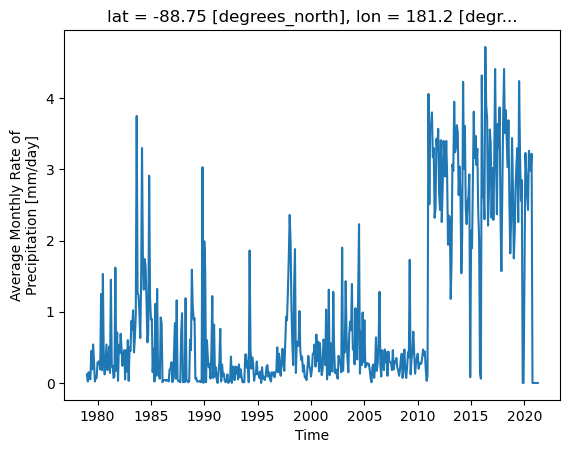

In [14]:
ds['precip'].isel(lat=-1).isel(lon=72).plot(label='Polar');

 Using `.sel`, we can use the **coordinate value** at the index rather than the index itself. Let's use `.sel` to look at the mean monthly precipitation near the equator, which is at a latitude of 0. We'll use the 72nd longitude value again.

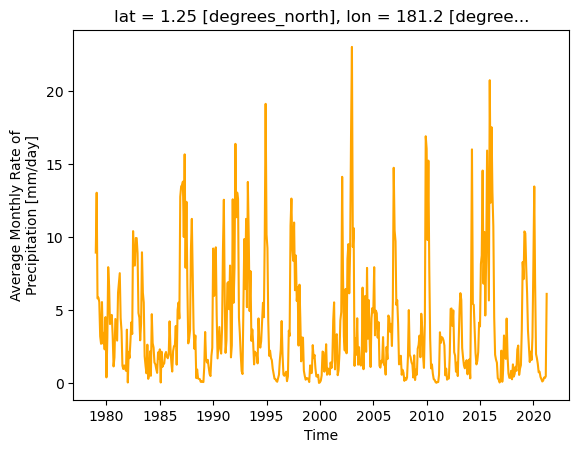

In [15]:
ds['precip'].sel(lat=1.25).isel(lon=72).plot(label='Equator', color='orange');

We can also put them on the same figure to better compare the values.

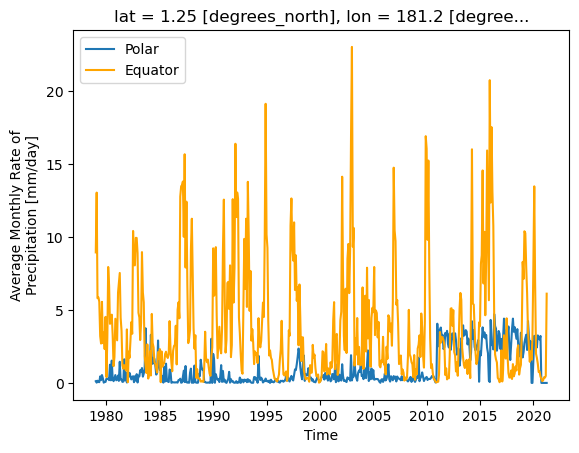

In [16]:
ds['precip'].isel(lat=-1, lon=72).plot(label='Polar'); # note we've combined the two isel commands, separated by a comma
ds['precip'].sel(lat=1.25).isel(lon=72).plot(label='Equator', color='orange');
plt.legend();

<font color="#0F766E"> Plot a time series of mean monthly precipitation at the second-from-northern-most point and a longitude of 1.25°. </font><br>


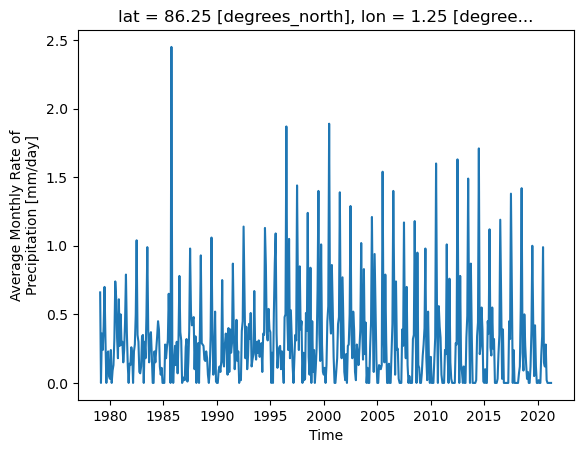

In [17]:
ds['precip'].isel(lat=1).sel(lon=1.25).plot();

<font color="#0F766E"> What is the difference between .isel and .sel? </font><br>
